# 03 Eval Results FINAL v2 PyTorch

This notebook evaluates the trained FiLM autoencoder on Alibaba-derived sliding windows. It injects synthetic anomalies for controlled experiments, computes reconstruction-error anomaly scores, reports classical metrics, evaluates early-detection criteria, and highlights the most anomalous windows and features.


In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from container_ad_pipeline.config import PipelineConfig, ensure_pipeline_directories
from container_ad_pipeline.dataset import build_dataset_from_raw_archives, load_dataset_bundle
from container_ad_pipeline.evaluate import (
    add_top_k_feature_columns,
    evaluate_predictions,
    inject_synthetic_anomalies,
    run_model_inference,
    save_evaluation_outputs,
)
from container_ad_pipeline.train import train_film_autoencoder, select_split

pd.set_option("display.max_columns", 200)
config = PipelineConfig()
ensure_pipeline_directories(config)

config.dataset.max_container_meta_files = 10
config.dataset.max_container_usage_files = 10
config.dataset.max_machine_meta_files = None
config.dataset.max_machine_usage_files = 10
config.dataset.max_usage_rows = 10_000
config.dataset.max_machine_usage_rows = 20_000
config.dataset.max_containers = 50
config.dataset.chunksize = 5_000

if not (config.paths.processed_dir / "X_all.npy").exists():
    build_dataset_from_raw_archives(config.paths, config.dataset, config.paths.processed_dir)

bundle = load_dataset_bundle(config.paths.processed_dir)
config.train.epochs = 30
config.train.patience = 8
config.train.batch_size = 128
if not config.paths.checkpoint_path.exists():
    train_film_autoencoder(
        bundle=bundle,
        train_config=config.train,
        checkpoint_path=config.paths.checkpoint_path,
        x_scaler_path=config.paths.x_scaler_path,
        c_scaler_path=config.paths.c_scaler_path,
        detector_meta_json=config.paths.detector_meta_json,
        detector_meta_joblib=config.paths.detector_meta_joblib,
    )

x_scaler = joblib.load(config.paths.x_scaler_path)
c_scaler = joblib.load(config.paths.c_scaler_path)
detector_meta = joblib.load(config.paths.detector_meta_joblib)
threshold = float(detector_meta["threshold"])

print(bundle.X.shape, bundle.C.shape)
print("Threshold:", threshold)


(163140, 24, 8) (163140, 17)
Threshold: 5.500068187713623


## Inject Synthetic Anomalies

Synthetic perturbations provide controlled anomaly labels without changing the underlying FiLM autoencoder. This lets the evaluation stay reproducible while preserving the unsupervised reconstruction-based detector.


In [2]:
X_test, _, test_meta = select_split(bundle, "test")
X_injected, y_true, events = inject_synthetic_anomalies(
    X_test,
    feature_columns=bundle.feature_meta["feature_columns"],
    anomaly_ratio=config.eval.anomaly_ratio,
    seed=config.eval.anomaly_seed,
)

print("Test windows:", len(X_test))
print("Injected anomalous windows:", int(y_true.sum()))
display(events.head())


Test windows: 24471
Injected anomalous windows: 2447


,event_id,start_window,end_window,anomaly_type,affected_features
0,0,14,14,noise,"[mem_util, cpu_util, mem_gps]"
1,1,53,53,drop,"[mem_gps, cpi]"
2,2,76,76,spike,[net_in]
3,3,77,77,spike,"[net_out, cpu_util, mpki]"
4,4,85,85,drop,[cpu_util]


## Run Inference And Compute Anomaly Scores

The trained autoencoder reconstructs each test window, and the anomaly score is computed from the mean feature-wise reconstruction error. The top-k feature contributors are then extracted for later qualitative analysis and GPT adjudication.


In [3]:
predictions = run_model_inference(
    bundle=bundle,
    model_path=config.paths.checkpoint_path,
    x_scaler=x_scaler,
    c_scaler=c_scaler,
    split_name="test",
    injected_X=X_injected,
)
predictions = add_top_k_feature_columns(predictions, bundle.feature_meta["feature_columns"], config.eval.top_k_features)
artifacts = evaluate_predictions(predictions, y_true, threshold, config.eval, events)
output_paths = save_evaluation_outputs(artifacts, config.paths.evaluation_dir, config.eval)

display(pd.Series(output_paths, name="evaluation_artifact"))


predictions      C:\Users\kaspe\Desktop\Project\project\artifac...
top_windows      C:\Users\kaspe\Desktop\Project\project\artifac...
summary          C:\Users\kaspe\Desktop\Project\project\artifac...
event_metrics    C:\Users\kaspe\Desktop\Project\project\artifac...
Name: evaluation_artifact, dtype: str

## Detection Metrics And Early-Detection Criteria

This section reports precision, recall, F1, PR-AUC, ROC-AUC, and both strict and relaxed event-level detection metrics. The strict criterion requires an alert exactly at the event onset, while the relaxed criterion allows a small delay.


threshold                   5.500068
precision                   0.164835
recall                      0.006130
f1                          0.011820
pr_auc                      0.496991
roc_auc                     0.916334
num_windows             24471.000000
num_positive_windows     2447.000000
Name: window_metrics, dtype: float64

strict_event_recall        0.006130
relaxed_event_recall       0.007765
mean_detection_delay       0.473684
num_events              2447.000000
Name: event_metrics, dtype: float64

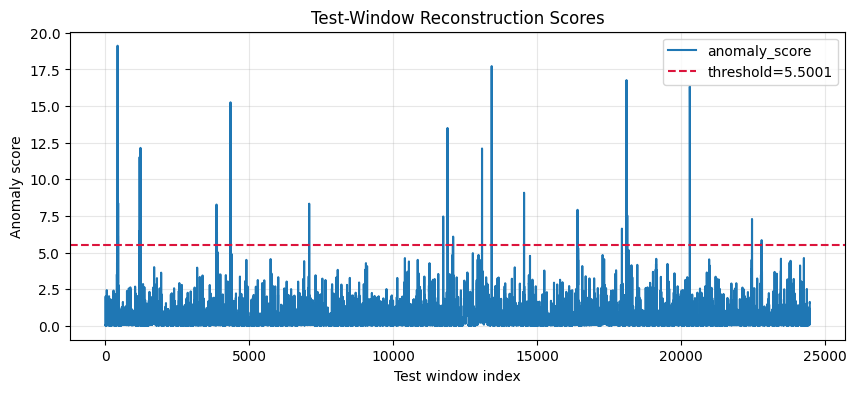

In [4]:
display(pd.Series(artifacts.summary, name="window_metrics"))
display(pd.Series(artifacts.event_metrics, name="event_metrics"))

score_df = artifacts.predictions.copy()
plt.figure(figsize=(10, 4))
plt.plot(score_df.index, score_df["anomaly_score"], label="anomaly_score")
plt.axhline(threshold, color="crimson", linestyle="--", label=f"threshold={threshold:.4f}")
plt.xlabel("Test window index")
plt.ylabel("Anomaly score")
plt.title("Test-Window Reconstruction Scores")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Visualize The Most Anomalous Windows

The highest-scoring windows are shown together with their top feature contributors. This links the quantitative evaluation back to specific containers and machines from the Alibaba traces.


,window_position,window_id,container_id,machine_id,app_du,container_status,machine_status,anomaly_score,top_k_features,top_k_feature_errors
0,428,42663,c_26776,m_1924,471.0,0.0,0.0,19.119314,"[mem_gps, disk_io, cpu_util, net_in, cpi]","[152.2934112548828, 0.4101439416408539, 0.0598..."
1,13421,77058,c_11474,m_2672,546.0,0.0,0.0,17.725811,"[mem_gps, disk_io, cpu_util, mem_util, cpi]","[140.2737579345703, 0.46682190895080566, 0.295..."
2,13420,9911,c_21383,m_1185,681.0,0.0,0.0,16.973057,"[mem_gps, disk_io, mem_util, cpu_util, mpki]","[134.02333068847656, 0.44150856137275696, 0.38..."
3,427,41984,c_26546,m_1903,533.0,0.0,0.0,16.877968,"[mem_gps, disk_io, cpi, mpki, cpu_util]","[134.35191345214844, 0.3202355206012726, 0.140..."
4,18104,158504,c_28294,m_913,190.0,0.0,0.0,16.771332,"[mem_gps, net_in, net_out, disk_io, cpu_util]","[127.94243621826172, 4.679785251617432, 0.5383..."
5,20302,48849,c_21403,m_2086,243.0,0.0,0.0,16.332026,"[mem_gps, disk_io, cpi, cpu_util, mpki]","[129.45542907714844, 0.3413223922252655, 0.270..."
6,429,81839,c_29214,m_2808,315.0,0.0,0.0,15.489549,"[mem_gps, disk_io, cpi, mem_util, net_in]","[122.95221710205078, 0.4650405943393707, 0.214..."
7,4350,82665,c_12432,m_2821,444.0,0.0,0.0,15.254930,"[mem_gps, net_in, cpi, net_out, disk_io]","[119.54683685302734, 0.7186281681060791, 0.669..."
8,13419,71368,c_11181,m_255,567.0,0.0,0.0,15.249006,"[mem_gps, mem_util, cpu_util, mpki, cpi]","[120.43314361572266, 0.5171049237251282, 0.346..."
9,20303,160334,c_16042,m_940,9.0,0.0,0.0,15.119082,"[mem_gps, disk_io, cpi, cpu_util, mpki]","[119.69603729248047, 0.38377663493156433, 0.27..."


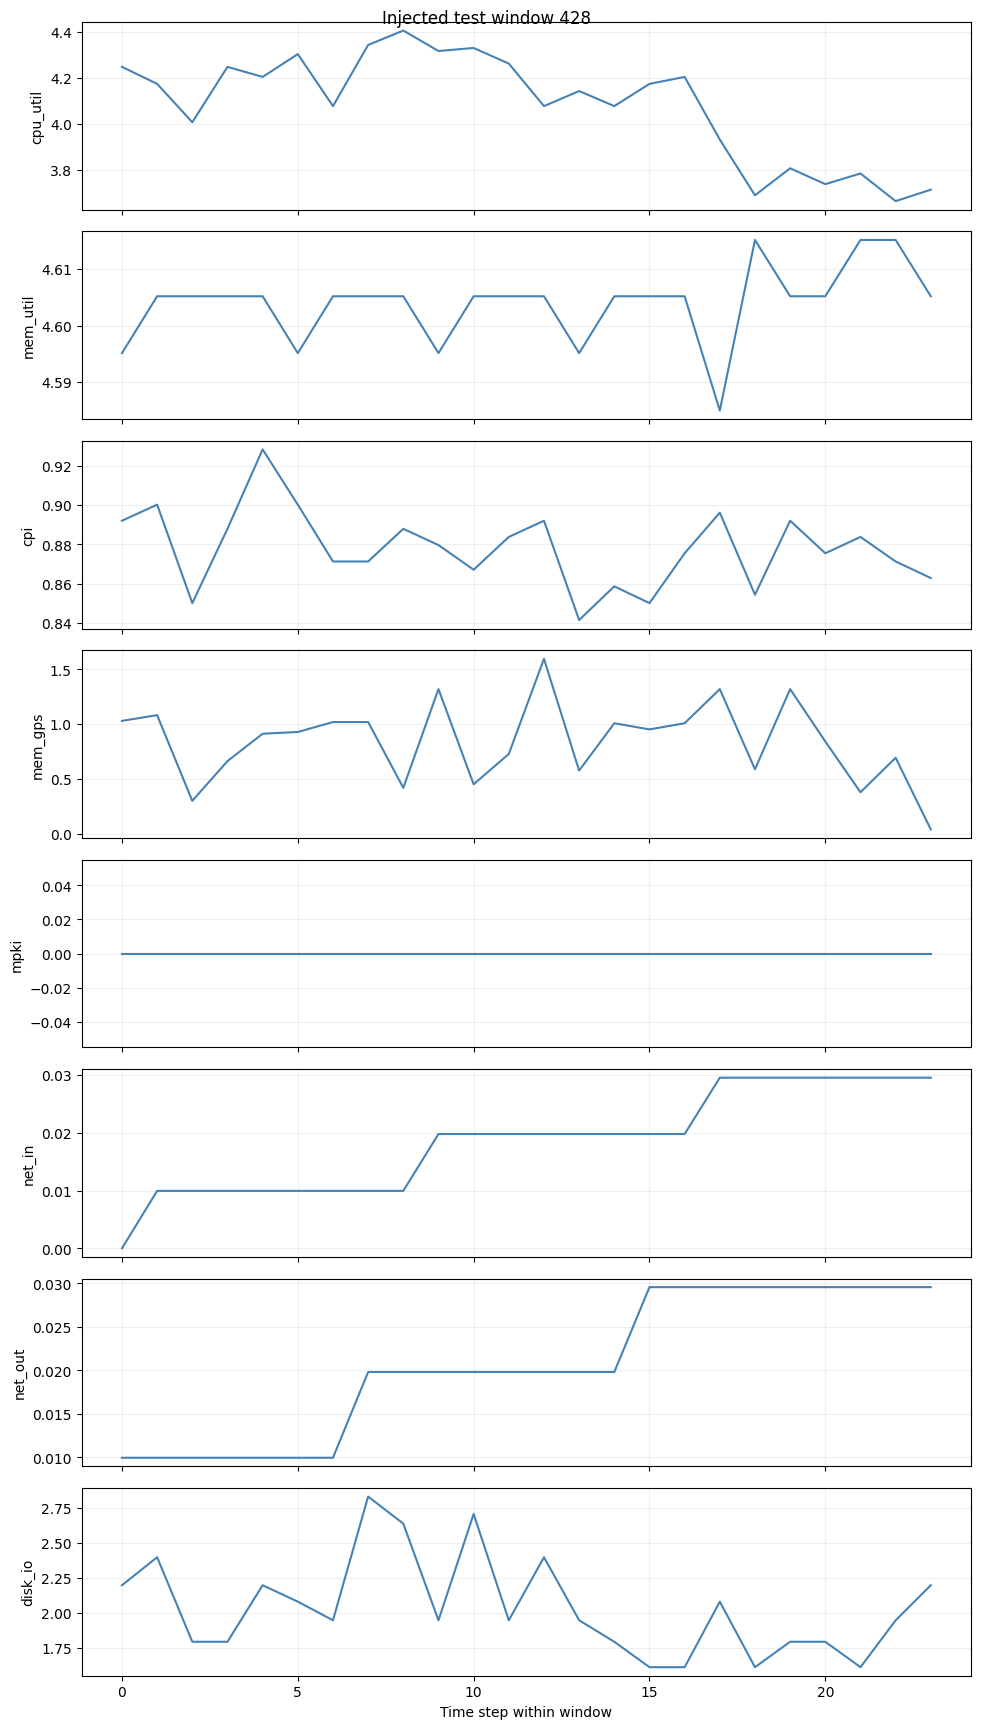

In [5]:
display(
    artifacts.top_windows[
        [
            "window_position",
            "window_id",
            "container_id",
            "machine_id",
            "app_du",
            "container_status",
            "machine_status",
            "anomaly_score",
            "top_k_features",
            "top_k_feature_errors",
        ]
    ].head(10)
)

def plot_window(window_position: int) -> None:
    window = X_injected[window_position]
    fig, axes = plt.subplots(len(bundle.feature_meta["feature_columns"]), 1, figsize=(10, 2.2 * len(bundle.feature_meta["feature_columns"])), sharex=True)
    if len(bundle.feature_meta["feature_columns"]) == 1:
        axes = [axes]
    for axis, feature_name, feature_values in zip(axes, bundle.feature_meta["feature_columns"], window.T):
        axis.plot(feature_values, color="steelblue")
        axis.set_ylabel(feature_name)
        axis.grid(alpha=0.2)
    axes[-1].set_xlabel("Time step within window")
    fig.suptitle(f"Injected test window {window_position}")
    fig.tight_layout()
    plt.show()

plot_window(int(artifacts.top_windows.iloc[0]["window_position"]))
